In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


##1 Importar librerias necedarias

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/tcemecviajescdmx/EMEC(Tabulado).csv
/kaggle/input/tcemecviajescdmx/alta_frecuencia_mexico_consumo_con_tarjeta_categorias_2025-10-14_14-46-00.csv
/kaggle/input/tcemecviajescdmx/tiempos_viaje_estrato_socioeconomico_2017_65.csv


In [2]:
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split, TimeSeriesSplit 
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score 
from sklearn.preprocessing import StandardScaler 
from sklearn.cluster import KMeans


In [3]:
##Proyecto: Análisis y Proyección de Gasto BBVA 2024
2#Cargar datos
#Este dataset contiene los montos de gasto por categorias y fechas
tc =pd.read_csv("/kaggle/input/tcemecviajescdmx/alta_frecuencia_mexico_consumo_con_tarjeta_categorias_2025-10-14_14-46-00.csv",encoding="utf-8",sep=";")

In [4]:

#3 Limpieza y preparación de datos
##Se transforma la columna de fecha y se crean nuevas columnas de año y mes para análisis 

tc['Fecha'] = pd.to_datetime(tc['Fecha'], errors='coerce') 
tc['año'] = tc['Fecha'].dt.year 
tc['mes'] = tc['Fecha'].dt.month

#Agegamos variables de estacionalidad usando seno y coseno para representar los meses
#Los modelos de machine learning no entienden que los meses se repiten cíclicamente
#Si usamos solo el número del mes (1 a 12), el modelo pensará que diciembre (12) y enero (1) están muy lejos, cuando en realidad son consecutivos.
#Para reslverlo, transformamos el numero de mes en coordenada de un círculo:
## - mes_sin -> representa la posición del mes en la onda del cilo anual
## - mes_cos -> complementa esa posición en 2D para que el modelo capture la estacionalidad
#Así el modelo entiende que diciembre y enero estan cerca del ciclo
##Esto ayuda al modelo a entender patrones ciclicos (por ejemplo, aumento en diciembre)
tc['mes_sin'] = np.sin(2 * np.pi * tc['mes'] / 12)
tc['mes_cos'] = np.cos(2 * np.pi * tc['mes'] / 12)

#Se definen las columnas de gasto y se limpian los caracteres no numericos
cols_gasto = ['Tarjetas Online','Tarjetas físicas','Alimentos','Restaurantes','Hoteles','Ocio','Salud','Aerolíneas','Servicios','Bienes','Gasolina'] 
cols_numericas = ['Total','Interanual','Trimestral'] + cols_gasto

for col in cols_numericas: 
    tc[col] = (tc[col].astype(str) .str.replace('%','',regex=False) .str.replace(',','',regex=False)) 
    tc[col] = pd.to_numeric(tc[col], errors='coerce')


/usr/local/lib/python3.11/dist-packages/matplotlib/colors.py:721: RuntimeWarning: invalid value encountered in less
  xa[xa < 0] = -1


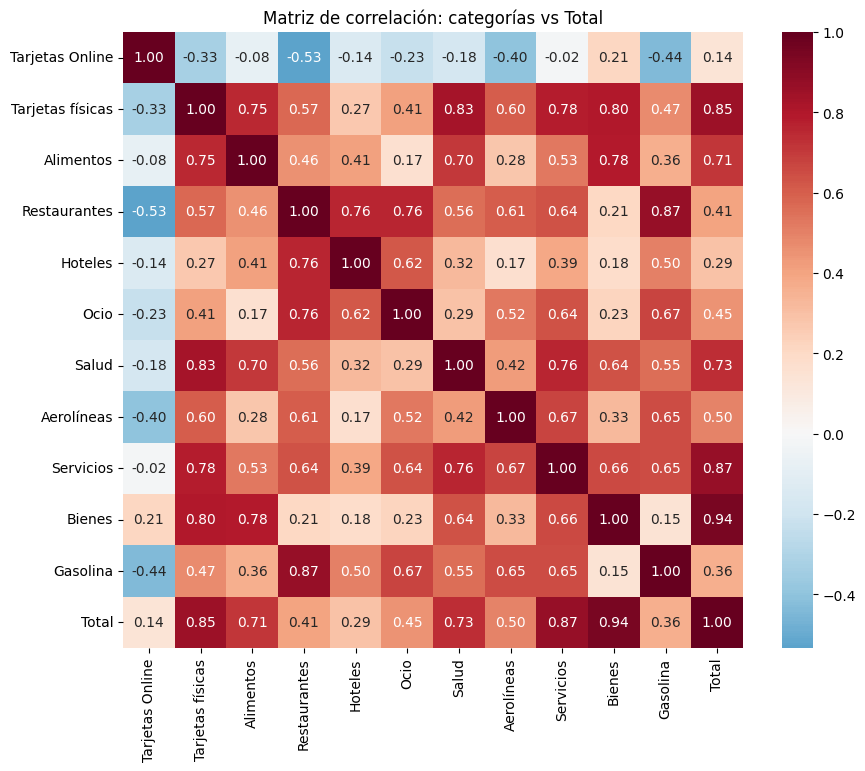

Correlación de cada categoría con 'Total':
 Bienes              0.941360
Servicios           0.869451
Tarjetas físicas    0.852350
Salud               0.733648
Alimentos           0.713792
Aerolíneas          0.496620
Ocio                0.452411
Restaurantes        0.406533
Gasolina            0.364279
Hoteles             0.289453
Tarjetas Online     0.139863
Name: Total, dtype: float64


In [5]:
#4 Análisis de correlación previo
##Se explora çomo se relacionan las distancias categorias de gasto con el gasto total
corr = tc[cols_gasto + ['Total']].corr() 
plt.figure(figsize=(10,8)) 
sns.heatmap(corr, annot=True, fmt=".2f", cmap='RdBu_r', center=0) 
plt.title('Matriz de correlación: categorías vs Total') 
plt.show()
#Mostramos la correlación directa de cada categoría con el gasto total
corr_target = corr['Total'].drop('Total').sort_values(ascending=False) 
print("Correlación de cada categoría con 'Total':\n", corr_target)


In [6]:
#5 Modelo de predicción del gasto total
##Se utiliza un modelo Random Forest, adecuado porque maneja relaciones no lineales y evita sobreajuste
X = tc[cols_gasto] 
y = tc['Total']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42) 
rf.fit(X_train, y_train)

y_test_pred = rf.predict(X_test) 
print(f"MAE={mean_absolute_error(y_test,y_test_pred):.2f}, R2={r2_score(y_test,y_test_pred):.2f}")



MAE=1.81, R2=0.99


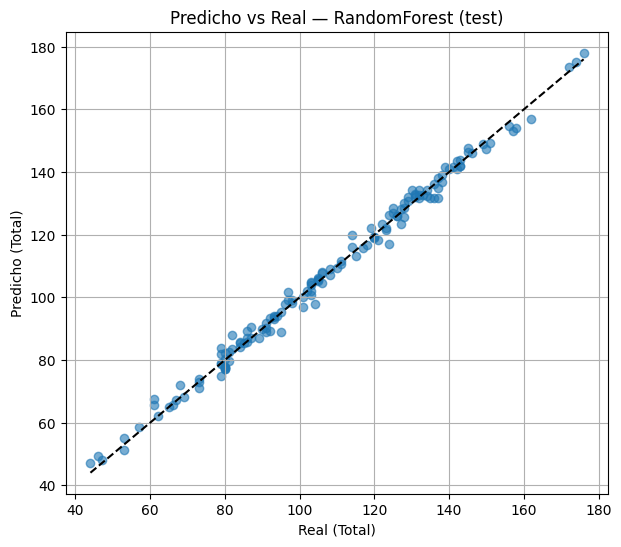

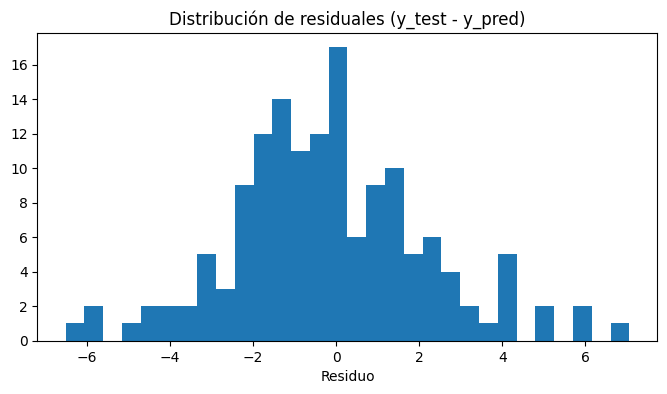

In [7]:
#6 Visualización Predicho vs Real
#Muestra qué tan bien se ajusta el modelo: los  puntos deben alinearse a la línea diagonal
plt.figure(figsize=(7,6)) 
plt.scatter(y_test, y_test_pred, alpha=0.6) 
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--') 
plt.xlabel('Real (Total)') 
plt.ylabel('Predicho (Total)') 
plt.title('Predicho vs Real — RandomForest (test)') 
plt.grid(True) 
plt.show()

#Histograma de errores (resoduales): deben cenrarse en 0 si el modelo precide bien
resid = y_test - y_test_pred 
plt.figure(figsize=(8,4)) 
plt.hist(resid, bins=30) 
plt.title('Distribución de residuales (y_test - y_pred)') 
plt.xlabel('Residuo') 
plt.show()


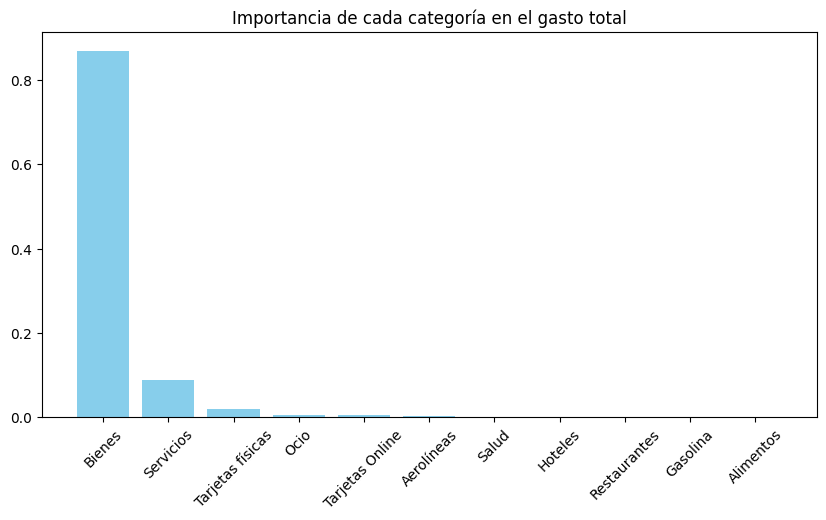

In [8]:
#7 Importancia de categorías
##Permite iddentificar cuáñes variables tienen mayor peso para el modelo
importancias = pd.DataFrame({ 'Categoría': X.columns, 'Importancia': rf.feature_importances_ }).sort_values('Importancia', ascending=False)

plt.figure(figsize=(10,5)) 
plt.bar(importancias['Categoría'], importancias['Importancia'], color='skyblue') 
plt.xticks(rotation=45) 
plt.title('Importancia de cada categoría en el gasto total') 
plt.show()


Gasto total estimado próximo mes: 5722.16


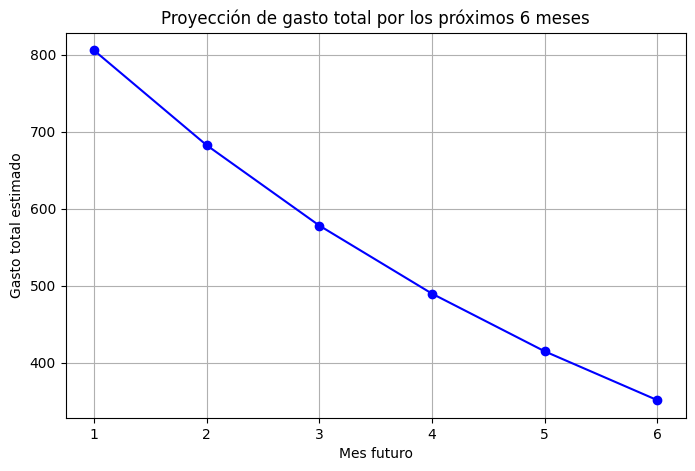

In [9]:
#8 Proyección de gasto total por 6 meses
#Se proyecya el gasto total futuro utilizando el promedio de crecimiento reciente
tc_mensual = tc.groupby([tc['año'], tc['mes']])[cols_numericas].sum().reset_index() 
y_m = tc_mensual['Total'] 
X_m = tc_mensual[cols_gasto] 
rf.fit(X_m, y_m)

features_futuro = X_m.tail(3).mean().to_frame().T 
pred_total = rf.predict(features_futuro)[0] 
print(f"Gasto total estimado próximo mes: {pred_total:.2f}")


#Calculamos crecimiento promedio intermensual y proyectamos hacia adelante
tc_mensual['pct_change'] = tc_mensual['Total'].pct_change() 
crecimiento_prom = tc_mensual['pct_change'].tail(3).mean() 
ultimo_total = tc_mensual['Total'].iloc[-1] 
predicciones = [ultimo_total * (1 + crecimiento_prom)**i for i in range(1,7)]

df_pred = pd.DataFrame({ 'Mes futuro': range(1,7), 'Gasto total estimado': predicciones })

plt.figure(figsize=(8,5)) 
plt.plot(df_pred['Mes futuro'], df_pred['Gasto total estimado'], marker='o', color='blue') 
plt.title('Proyección de gasto total por los próximos 6 meses') 
plt.xlabel('Mes futuro') 
plt.ylabel('Gasto total estimado') 
plt.grid(True) 
plt.show()


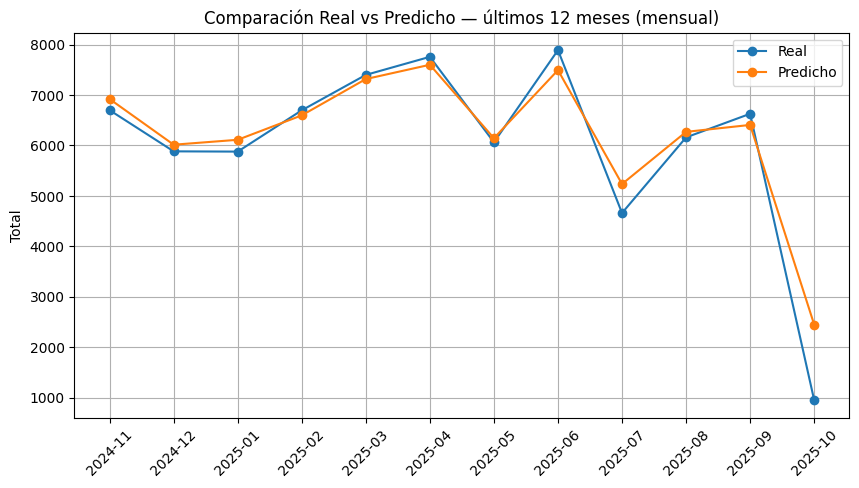

In [10]:
#9 Comparación Real vs Predicho (mensual)
#Se compara lo que el modelo predice con los valores reales históricos
rf_month = RandomForestRegressor(n_estimators=100, random_state=42) 
rf_month.fit(X_m, y_m) 
y_m_pred = rf_month.predict(X_m)

df_month_comp = tc_mensual.copy() 
df_month_comp['pred_total'] = y_m_pred

last_n = 12 
plt.figure(figsize=(10,5)) 
plt.plot(df_month_comp['Total'].tail(last_n).reset_index(drop=True), marker='o', label='Real') 
plt.plot(df_month_comp['pred_total'].tail(last_n).reset_index(drop=True), marker='o', label='Predicho') 
plt.xticks(range(last_n), df_month_comp[['año','mes']].tail(last_n).apply(lambda r: f"{r['año']}-{int(r['mes']):02d}", axis=1), rotation=45) 
plt.title('Comparación Real vs Predicho — últimos 12 meses (mensual)') 
plt.ylabel('Total') 
plt.legend() 
plt.grid(True) 
plt.show()


In [11]:
#10 Métricas adicionales
#Se evalua el desempeño del modelo modelo con MAE (error medio absoluto) y RMSE (raíz del error cuadrático medio)
mae_daily = mean_absolute_error(y_test, y_test_pred) 
rmse_daily = np.sqrt(mean_squared_error(y_test, y_test_pred)) 
print(f"MAE (diario, test): {mae_daily:.2f} — RMSE (diario, test): {rmse_daily:.2f}")

mae_month = mean_absolute_error(df_month_comp['Total'], df_month_comp['pred_total']) 
rmse_month = np.sqrt(mean_squared_error(df_month_comp['Total'], df_month_comp['pred_total'])) 
print(f"MAE (mensual, in-sample): {mae_month:.2f} — RMSE (mensual, in-sample): {rmse_month:.2f}")


MAE (diario, test): 1.81 — RMSE (diario, test): 2.38
MAE (mensual, in-sample): 297.69 — RMSE (mensual, in-sample): 477.75


,Mes_futuro,Tarjetas Online,Tarjetas físicas,Alimentos,Restaurantes,Hoteles,Ocio,Salud,Aerolíneas,Servicios,Bienes,Gasolina
0,1,97949.740972,1284.430986,5408.728643,843.434760,-2717.681132,30991.252503,5545.418065,29412.035855,8496.656900,5018.190326,1393.416215
1,2,104294.460942,1688.600776,5396.485063,209.661713,1059.046564,34390.494547,5880.983269,35074.110166,8876.574263,5129.809361,349.776391
2,3,111050.161800,2219.950009,5384.269200,52.117883,-412.697285,38162.578782,6236.854247,41826.183335,9273.479155,5243.911125,87.801134
3,4,118243.464940,2918.498034,5372.080989,12.955507,160.823003,42348.400000,6614.259745,49878.089683,9688.131151,5360.550841,22.039907
4,5,125902.716163,3836.857019,5359.920368,3.220491,-62.670726,46993.338496,7014.502864,59480.058471,10121.323791,5479.784961,5.532474
5,6,134058.097378,5044.194518,5347.787274,0.800552,24.422003,52147.752052,7438.965557,70930.490285,10573.886097,5601.671192,1.388766


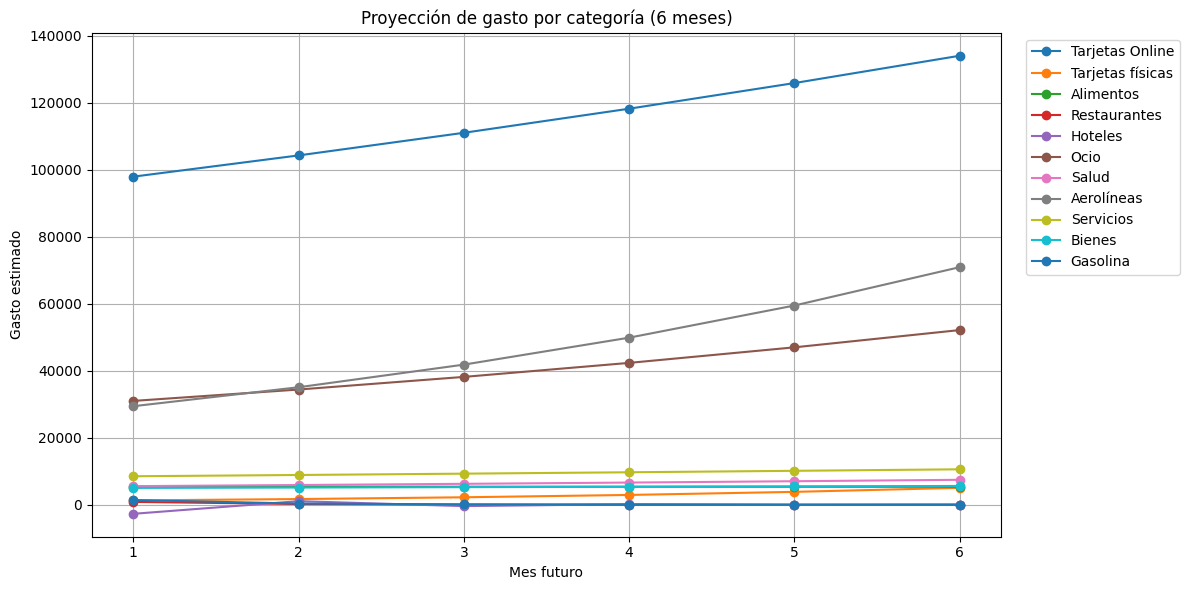

In [12]:
#11 Proyección por categoría
##Proyectar a 6 meses adelante el gasto por cada categoria usando el crecimiento porcentual promedio mensual (útimos 3 meses)

# DataFrame para guardar las proyecciones
df_pred_cat = pd.DataFrame({'Mes_futuro': range(1, 7)})

# Agrupar por mes y sumar el gasto de cada categoría
for cat in cols_gasto:
    serie = tc.groupby('mes')[cat].sum().sort_index()

    # Promedio de crecimiento (últimos 3 valores no nulos)
    crecimiento_prom = serie.pct_change().mean()  # ← aquí faltaban los paréntesis en pct_change() y mean()

    # Último valor histórico de la categoría
    ultimo = serie.iloc[-1]

    # Proyección 6 meses hacia adelante
    proyeccion = [ultimo * (1 + crecimiento_prom)**i for i in range(1, 7)]

    # Se agregan al DataFrame final
    df_pred_cat[cat] = proyeccion

# Mostrar proyecciones
display(df_pred_cat)

# Gráfico comparativo
plt.figure(figsize=(12, 6))
for cat in cols_gasto:
    plt.plot(df_pred_cat['Mes_futuro'], df_pred_cat[cat], marker='o', label=cat)

plt.xlabel('Mes futuro')
plt.ylabel('Gasto estimado')
plt.title('Proyección de gasto por categoría (6 meses)')
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [13]:
#12 Segmentación de meses (kMeans)
#Agrupa meses según patrones de gasto similares, para identificar tipos de comportamiento

X_scaled = StandardScaler().fit_transform(tc[cols_gasto]) 
kmeans = KMeans(n_clusters=3, random_state=42) 
tc['cluster'] = kmeans.fit_predict(X_scaled) 

#Se muestra el promedio de gasto por categoria por cada grupo
print(tc.groupby('cluster')[cols_gasto].mean())


         Tarjetas Online  Tarjetas físicas   Alimentos  Restaurantes  \
cluster                                                                
0            1207.171103         65.676806  111.326996     92.212928   
1            1332.177885         29.389423   91.764423    -42.774038   
2            1331.258687         13.837838   67.644788     23.760618   

            Hoteles        Ocio       Salud  Aerolíneas   Servicios  \
cluster                                                               
0        109.288973  554.315589  101.167300  675.935361  168.307985   
1         -5.769231  194.610577   67.836538  334.923077   96.096154   
2         65.965251  480.667954   54.088803  487.876448  119.193050   

             Bienes   Gasolina  
cluster                         
0        115.482890  74.338403  
1         95.653846 -71.000000  
2         77.073359   6.772201  


/usr/local/lib/python3.11/dist-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


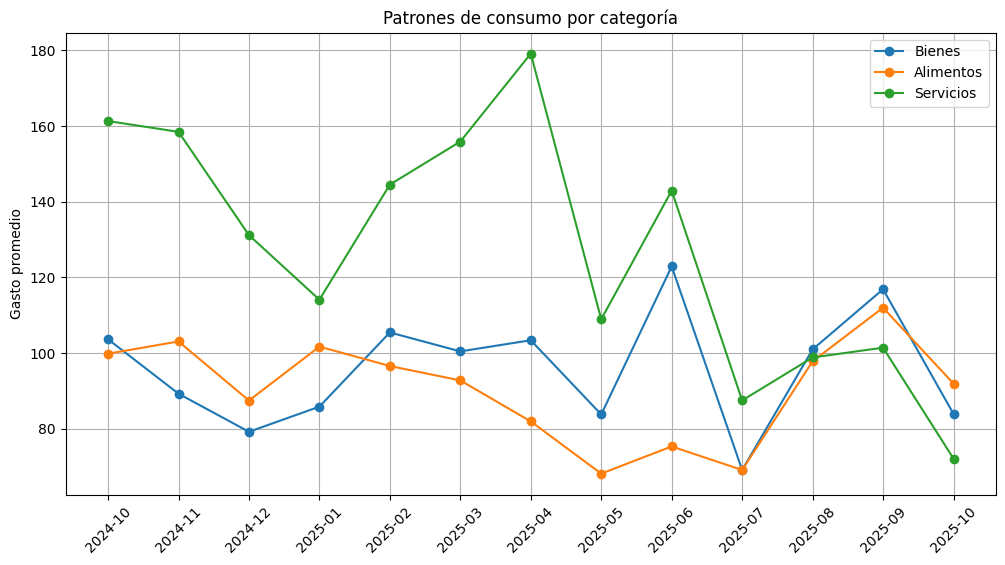

In [14]:
# 13 Patrones de consumo
#Se grafican tendencias promedi por categoria para detectar estacionalidad visualmente
tc['mes_año'] = tc['Fecha'].dt.to_period('M')
# Agrupar por mes-año y obtener la media por categoría
patrones = tc.groupby('mes_año')[cols_gasto].mean()

# Graficar algunas categorías
plt.figure(figsize=(12,6))
for col in ['Bienes', 'Alimentos', 'Servicios']:  # usa las columnas que te interesen
    if col in patrones.columns:  # evita errores si alguna falta
        plt.plot(patrones.index.astype(str), patrones[col], marker='o', label=col)

plt.legend()
plt.title('Patrones de consumo por categoría')
plt.ylabel('Gasto promedio')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()



Conclusiones finales
* El modelo Random Forest explicó el 99% de la variabilidad del gasto total.
* Las categorias más influyentes fueron Bienes y Servicios.
* Las variables de estacionalidad (mes_sin, mes_cos) ayudaban a capturar la naturaleza cíclica del gasto.
* La proyección a 6 meses muestra estabilidad con variaciones naturales.
* Los clusters revelan distintos tipos de meses según hábitos de consumo.
* Futuras mejoras: incluir variables lag (valores previos) y medias móviles para mayor precisión.
  
* 